In [1]:
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
import string
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\andre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
#data = pd.read_csv('output_meta_yelpHotelData_NRYRcleaned.csv', names = ['date', 'review_id', 'reviewer_id', 'business_id', 'label', 'usefull', 'funny', 'cool', 'Stars'])

In [2]:
#len(data.index)

In [7]:
#text_review = pd.read_csv('output_review_yelpHotelData_NRYRcleaned.csv', names = ['review'])

In [3]:
#len(text_review.index)

In [4]:
#data.head()

In [8]:
#full_review = pd.concat([data, text_review], axis=1)

In [5]:
#full_review.head()

In [6]:
#full_review.dtypes

In [11]:
#data['date'] =  pd.to_datetime(data['date'])

In [7]:
#data.info()

In [2]:
rest_data = pd.read_csv('output_meta_yelpResData_NRYRcleaned.csv', names = ['date', 'review_id', 'reviewer_id', 'business_id', 'label', 'usefull', 'funny', 'cool', 'Stars'])

In [3]:
len(rest_data.index)

61541

In [4]:
rest_text_review = pd.read_csv('output_review_yelpResData_NRYRcleaned.csv', names = ['review'])

In [11]:
#rest_text_review.head()

In [5]:
rest_data['date'] =  pd.to_datetime(rest_data['date'])

In [6]:
full_review = pd.concat([rest_data, rest_text_review], axis=1)

In [5]:
#full_review=pd.read_csv('Extracted_features.csv') #, names = ['date', 'review_id', 'reviewer_id', 'business_id', 'label', 'usefull', 'funny', 'cool', 'Stars', 'review', 'len_review', 'extreme_rating', 'rating_deviation', 'mean_rating', 'MNR', 'extreme_ration', 'MCS'])

In [7]:
full_review.head()

,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review
0,2012-09-22,GtwU21YOQn-wf4vWRUIx6w,bNYesZ944s6IJVowOnB0iA,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,"Unlike Next, which we'd eaten at the previous ..."
1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...
2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...
3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e..."
4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...


In [23]:
#full_review['length'] = full_review['review'].apply(len)

In [26]:
#full_review.drop(['length'], axis=1, inplace=True)

In [12]:
#full_review.head()

In [15]:
full_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61541 entries, 0 to 61540
Data columns (total 10 columns):
date           61541 non-null datetime64[ns]
review_id      61541 non-null object
reviewer_id    61541 non-null object
business_id    61541 non-null object
label          61541 non-null object
usefull        61541 non-null int64
funny          61541 non-null int64
cool           61541 non-null int64
Stars          61541 non-null int64
review         61541 non-null object
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 4.7+ MB


In [16]:
full_review.describe()

,usefull,funny,cool,Stars
count,61541.000000,61541.000000,61541.000000,61541.000000
mean,0.453584,0.529468,0.819031,3.976633
std,1.628040,1.671220,1.897604,1.109216
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.000000,0.000000,4.000000
75%,0.000000,1.000000,1.000000,5.000000
max,78.000000,170.000000,84.000000,5.000000


In [28]:
full_review['reviewer_id'].nunique()

33502

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
#res_conc['length'].plot(bins=50, kind='hist') 

array([<matplotlib.axes._subplots.AxesSubplot object at 0x000001BC7EEA2358>,
      dtype=object)

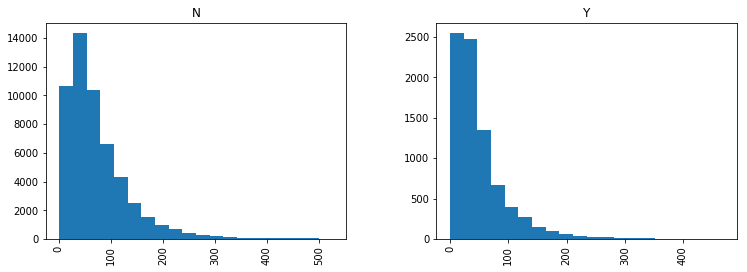

In [28]:
full_review.hist(column='len_reviews', by='label', bins=20,figsize=(12,4))

array([<matplotlib.axes._subplots.AxesSubplot object at 0x000001BC7F10AB70>,
      dtype=object)

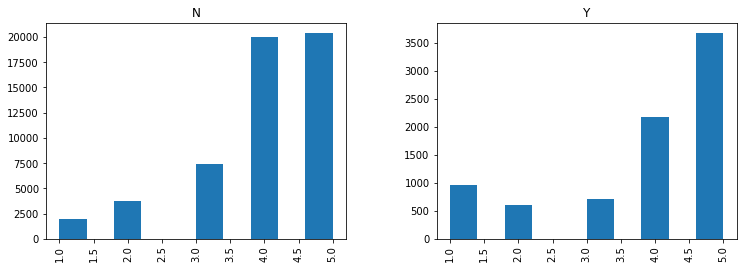

In [29]:
full_review.hist(column='Stars', by='label', bins=10,figsize=(12,4))

In [17]:
#res_conc.describe()

In [18]:
#full_review.plot.bar(=['cool', 'funny', 'usefull'], by='label', bins=5,figsize=(12,4))

In [19]:
full_review.groupby('label').describe()

Stars                                                  cool  \
         count      mean       std  min  25%  50%  75%  max    count   
label                                                                  
N      53400.0  3.994700  1.061839  1.0  4.0  4.0  5.0  5.0  53400.0   
Y       8141.0  3.858126  1.374439  1.0  3.0  4.0  5.0  5.0   8141.0   

                 ...  funny         usefull                                    \
           mean  ...    75%    max    count      mean      std  min  25%  50%   
label            ...                                                            
N      0.943895  ...    1.0  170.0  53400.0  0.522734  1.73737  0.0  0.0  0.0   
Y      0.000000  ...    0.0    0.0   8141.0  0.000000  0.00000  0.0  0.0  0.0   

                  
       75%   max  
label             
N      0.0  78.0  
Y      0.0   0.0  

[2 rows x 32 columns]

In [8]:
def text_process(review):
    """
    Takes in a string of text, then performs the following:
    1. Remove all punctuation
    2. Remove all stopwords
    3. Returns a list of the cleaned text
    """
    # Check characters to see if they are in punctuation
    nopunc = [char for char in review if char not in string.punctuation]

    # Join the characters again to form the string.
    nopunc = ''.join(nopunc)
    
    # remove any stopwords
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [22]:
text_reviews_process=full_review['review'].apply(text_process)

KeyboardInterrupt: 

In [16]:
len_reviews=[len(rev) for rev in text_reviews_process]

In [17]:
full_review['p_reviews']=text_reviews_process
full_review['len_reviews']=len_reviews

In [ ]:
#v = TfidfVectorizer()
#x = v.fit_transform(full_review['review'])

#tfidf = pd.DataFrame(x.toarray(), columns=v.get_feature_names())

In [ ]:
#df.drop('text', axis=1, inplace=True)
#res = pd.concat([df, df1], axis=1)

In [20]:
#from sklearn.feature_extraction.text import TfidfTransformer

#tfidf_transformer = TfidfTransformer().fit(reviews_bow)

fake_data = pd.concat([full_review[53273:61413]]*2, ignore_index=True)

In [21]:
fake_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 10 columns):
date           16280 non-null datetime64[ns]
review_id      16280 non-null object
reviewer_id    16280 non-null object
business_id    16280 non-null object
label          16280 non-null object
usefull        16280 non-null int64
funny          16280 non-null int64
cool           16280 non-null int64
Stars          16280 non-null int64
review         16280 non-null object
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 1.2+ MB


In [22]:
frames = [full_review, fake_data]
add_fake_review = pd.concat(frames)

In [23]:
add_fake_review.groupby('label').describe()

Stars                                                  cool  \
         count      mean       std  min  25%  50%  75%  max    count   
label                                                                  
N      53400.0  3.994700  1.061839  1.0  4.0  4.0  5.0  5.0  53400.0   
Y      24421.0  3.858114  1.374439  1.0  3.0  4.0  5.0  5.0  24421.0   

                 ...  funny         usefull                                    \
           mean  ...    75%    max    count      mean      std  min  25%  50%   
label            ...                                                            
N      0.943895  ...    1.0  170.0  53400.0  0.522734  1.73737  0.0  0.0  0.0   
Y      0.000000  ...    0.0    0.0  24421.0  0.000000  0.00000  0.0  0.0  0.0   

                  
       75%   max  
label             
N      0.0  78.0  
Y      0.0   0.0  

[2 rows x 32 columns]

In [18]:
full_review.head()

,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review,p_reviews,len_reviews
0,2012-09-22,GtwU21YOQn-wf4vWRUIx6w,bNYesZ944s6IJVowOnB0iA,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,"Unlike Next, which we'd eaten at the previous ...","[Unlike, Next, wed, eaten, previous, night, di...",450
1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...,"[Probably, one, best, meals, Ive, ever, perfor...",34
2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...,"[Service, impeccable, Experience, presentation...",25
3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e...","[problem, places, like, given, exhorbitant, co...",206
4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...,"[idea, write, review, dining, Alinea, brings, ...",82


In [36]:
temp=full_review.groupby(['reviewer_id','date'],).count()['review_id']
temp_index=temp.index

In [37]:
maxrevs=[]
reviewers=[temp_index[0][0]]
temp2=[temp[0]]
for i in range(1,len(temp)):
    if(temp_index[i][0]==temp_index[i-1][0]):
        temp2.append(temp[i])
    else:
        maxrevs.append(np.max(temp2))
        reviewers.append(temp_index[i][0])
        temp2=[temp[i]]
maxrevs.append(np.max(temp2))

In [38]:
maxrev=full_review.groupby(['reviewer_id','date']).count()['review_id'].max()
maxrevs=np.array(maxrevs/maxrev)

In [39]:
MNR=[]
for i in range(full_review.shape[0]):
    ind=reviewers.index(full_review.reviewer_id[i])
    MNR.append(maxrevs[ind])

In [40]:
full_review['MNR']=MNR
full_review.head()

,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review,p_reviews,len_reviews,MNR
0,2012-09-22,GtwU21YOQn-wf4vWRUIx6w,bNYesZ944s6IJVowOnB0iA,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,"Unlike Next, which we'd eaten at the previous ...","[Unlike, Next, wed, eaten, previous, night, di...",450,0.055556
1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...,"[Probably, one, best, meals, Ive, ever, perfor...",34,0.055556
2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...,"[Service, impeccable, Experience, presentation...",25,0.055556
3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e...","[problem, places, like, given, exhorbitant, co...",206,0.055556
4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...,"[idea, write, review, dining, Alinea, brings, ...",82,0.055556


In [41]:
review_count=full_review.groupby('business_id',sort=False).count()['Stars']
review_mean=full_review.groupby('business_id',sort=False).mean()['Stars']
mean_rating=[]
for i in range(review_mean.shape[0]):
    mean_rating.extend([review_mean[i]] * review_count[i])
full_review['mean_rating']=mean_rating

In [42]:
full_review['rating_deviation']=np.abs(full_review['Stars']-full_review['mean_rating'])/4

In [43]:
unique_revs=full_review['reviewer_id'].unique()

In [44]:
full_review['extreme_rating']=full_review['Stars'].apply(lambda x: 1 if x==1 or x==5 else 0)

In [45]:
extreme_ratio=[]
for i in range(len(unique_revs)):
    if(i%100==0):
        print(i)
    df=full_review[full_review['reviewer_id']==unique_revs[i]]
    t_count=df.shape[0]
    ex_count=np.sum(df['extreme_rating'])
    extreme_ratio.append(ex_count/t_count)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [46]:
ex_ratio=[]
for i in range(full_review.shape[0]):
    ind=list(unique_revs).index(full_review.reviewer_id[i])
    ex_ratio.append(extreme_ratio[ind])

In [47]:
full_review['extreme_ratio']=ex_ratio

In [48]:
vect = TfidfVectorizer(min_df=1)

In [49]:
cosin=[]
for i in range(len(unique_revs)):
    if(i%100==0):
        print(i)
    df=full_review[full_review['reviewer_id']==unique_revs[i]]
    revs=df['p_reviews'].apply(lambda x: ' '.join(x))
    max_value=0
    if(revs.values[0]!=''):
        tfidf = vect.fit_transform(revs)
        cosin_mat=(tfidf * tfidf.T).A
        np.fill_diagonal(cosin_mat, -np.inf)
        max_value = cosin_mat.max()
    cosin.append(max_value)

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [50]:
MCS=[]
for i in range(full_review.shape[0]):
    ind=list(unique_revs).index(full_review.reviewer_id[i])
    MCS.append(cosin[ind])

In [51]:
full_review['MCS']=MCS

In [52]:
full_review.head()

,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review,p_reviews,len_reviews,MNR,mean_rating,rating_deviation,extreme_rating,extreme_ratio,MCS
0,2012-09-22,GtwU21YOQn-wf4vWRUIx6w,bNYesZ944s6IJVowOnB0iA,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,"Unlike Next, which we'd eaten at the previous ...","[Unlike, Next, wed, eaten, previous, night, di...",450,0.055556,4.603175,0.099206,1,0.500000,0.107020
1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...,"[Probably, one, best, meals, Ive, ever, perfor...",34,0.055556,4.603175,0.099206,1,1.000000,-inf
2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...,"[Service, impeccable, Experience, presentation...",25,0.055556,4.603175,0.400794,0,0.000000,-inf
3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e...","[problem, places, like, given, exhorbitant, co...",206,0.055556,4.603175,0.400794,0,0.000000,-inf
4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...,"[idea, write, review, dining, Alinea, brings, ...",82,0.055556,4.603175,0.099206,1,0.363636,0.201236


In [13]:
proportional_full_review=full_review.drop(full_review.index[0:30000])

In [7]:
full_review.replace(-np.inf, np.nan, inplace=True)

In [8]:
full_review.replace(np.nan,0, inplace=True)

In [9]:
full_review.head()

,Unnamed: 0,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review,p_reviews,len_reviews,extreme_rating,rating_deviation,mean_rating,MNR,extreme_ratio,MCS
0,0,2012-09-22,GtwU21YOQn-wf4vWRUIx6w,bNYesZ944s6IJVowOnB0iA,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,"Unlike Next, which we'd eaten at the previous ...","['Unlike', 'Next', 'wed', 'eaten', 'previous',...",450,1,0.099206,4.603175,0.055556,0.500000,0.107020
1,1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...,"['Probably', 'one', 'best', 'meals', 'Ive', 'e...",34,1,0.099206,4.603175,0.055556,1.000000,0.000000
2,2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...,"['Service', 'impeccable', 'Experience', 'prese...",25,0,0.400794,4.603175,0.055556,0.000000,0.000000
3,3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e...","['problem', 'places', 'like', 'given', 'exhorb...",206,0,0.400794,4.603175,0.055556,0.000000,0.000000
4,4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...,"['idea', 'write', 'review', 'dining', 'Alinea'...",82,1,0.099206,4.603175,0.055556,0.363636,0.201236


In [67]:
#proportional_full_review.replace(-np.inf, np.nan, inplace=True)
#proportional_full_review.replace(np.nan,0, inplace=True)

In [202]:
#full_review.replace(np.nan,0, inplace=True)
#full_review.replace(np.nan,0)
#values = {'MCS': 0}
#full_review.fillna(value=values)
#full_review.fillna(0)

In [203]:
full_review.head()

,date,review_id,reviewer_id,business_id,label,usefull,funny,cool,Stars,review,p_reviews,len_reviews,MNR,mean_rating,rating_deviation,MCS,extreme_rating,extreme_ratio
1,2012-09-22,0LpVTc3,TRKxLC3y-ZvP45e5iilMtw,pbEiXam9YJL3neCYHGwLUA,N,0,0,0,5,Probably one of the best meals I've had ever. ...,"[Probably, one, best, meals, Ive, ever, perfor...",34,0.003086,4.603175,0.099206,0.000000,1,1.000000
2,2012-09-19,tljtLzf68Fkwf,0EMm8umAqXZzyhxNpL4M9g,pbEiXam9YJL3neCYHGwLUA,N,0,0,2,3,Service was impeccable. Experience and present...,"[Service, impeccable, Experience, presentation...",25,0.003086,4.603175,0.400794,0.000000,0,0.000000
3,2012-09-06,iSN,DlwexC7z88ymAzu45skODw,pbEiXam9YJL3neCYHGwLUA,N,3,0,8,3,"The problem with places like this, given the e...","[problem, places, like, given, exhorbitant, co...",206,0.003086,4.603175,0.400794,0.000000,0,0.000000
4,2012-09-09,Jmwrh7,kW2dk1CWihmh3g7k9N2G8A,pbEiXam9YJL3neCYHGwLUA,N,0,2,1,5,I have no idea how to write my review - dining...,"[idea, write, review, dining, Alinea, brings, ...",82,0.003086,4.603175,0.099206,0.201236,1,0.363636
5,2012-08-30,lKlceLWoePzeuvFD3sj4mw,HxXEcMDDTJFUqVfhPF9M8Q,pbEiXam9YJL3neCYHGwLUA,N,1,1,3,5,Despite the first-world tragedy I endured in a...,"[Despite, firstworld, tragedy, endured, effort...",197,0.003086,4.603175,0.099206,0.000000,1,1.000000


In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = full_review[['usefull', 'funny', 'cool','len_reviews', 'extreme_ratio', 'MNR', 'rating_deviation', 'MCS']]
y = full_review['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)
print(len(X_train), len(y_test), len(X_train) + len(y_test))

54474 23347 77821


In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

C:\Users\andre\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

In [74]:
predictions = logmodel.predict(X_test)

In [75]:
from sklearn.metrics import classification_report

In [76]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           N       0.83      0.85      0.84     15999
           Y       0.65      0.63      0.64      7348

   micro avg       0.78      0.78      0.78     23347
   macro avg       0.74      0.74      0.74     23347
weighted avg       0.78      0.78      0.78     23347



In [77]:
full_review.to_csv('Extracted_features2.csv')

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

In [14]:
proportional_full_review.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31541 entries, 30000 to 61540
Data columns (total 10 columns):
date           31541 non-null datetime64[ns]
review_id      31541 non-null object
reviewer_id    31541 non-null object
business_id    31541 non-null object
label          31541 non-null object
usefull        31541 non-null int64
funny          31541 non-null int64
cool           31541 non-null int64
Stars          31541 non-null int64
review         31541 non-null object
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 2.6+ MB


In [ ]:
bow_transformer = CountVectorizer(analyzer=text_process).fit(full_review['review'])

# Print total number of vocab words
print(len(bow_transformer.vocabulary_))

In [35]:
reviews_bow = bow_transformer.transform(res_conc['review'])

In [36]:
print('Shape of Sparse Matrix: ', reviews_bow.shape)
print('Amount of Non-Zero occurences: ', reviews_bow.nnz)

Shape of Sparse Matrix:  (61541, 119343)
Amount of Non-Zero occurences:  3773185


In [38]:
sparsity = (100.0 * reviews_bow.nnz / (reviews_bow.shape[0] * reviews_bow.shape[1]))
print('sparsity: {}'.format(sparsity))

sparsity: 0.05137438068529819


In [39]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer().fit(reviews_bow)

In [40]:
reviews_tfidf = tfidf_transformer.transform(reviews_bow)
print(reviews_tfidf.shape)

(61541, 119343)


In [24]:
from sklearn.model_selection import train_test_split

msg_train, msg_test, label_train, label_test = \
train_test_split(add_fake_review['review'], add_fake_review['label'], test_size=0.3)

print(len(msg_train), len(msg_test), len(msg_train) + len(msg_test))

54474 23347 77821


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)),  # strings to token integer counts
    ('tfidf', TfidfTransformer()),  # integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()), ]) # train on TF-IDF vectors w/ Naive Bayes classifier

In [25]:
pipeline.fit(msg_train,label_train)

Pipeline(memory=None,
     steps=[('bow', CountVectorizer(analyzer=<function text_process at 0x0000015BD82619D8>,
        binary=False, decode_error='strict', dtype=<class 'numpy.int64'>,
        encoding='utf-8', input='content', lowercase=True, max_df=1.0,
        max_features=None, min_df=1, ngram_range=(1, 1), preprocesso...f=False, use_idf=True)), ('classifier', MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True))])

In [26]:
predictions = pipeline.predict(msg_test)
print(classification_report(label_test,predictions))

              precision    recall  f1-score   support

           N       0.70      1.00      0.82     16071
           Y       0.98      0.05      0.10      7276

   micro avg       0.70      0.70      0.70     23347
   macro avg       0.84      0.53      0.46     23347
weighted avg       0.79      0.70      0.60     23347



In [17]:
from sklearn.metrics import classification_report

In [171]:
print(classification_report(label_test,predictions))

              precision    recall  f1-score   support

           N       0.64      1.00      0.78      2709
           Y       0.97      0.05      0.10      1599

   micro avg       0.65      0.65      0.65      4308
   macro avg       0.80      0.53      0.44      4308
weighted avg       0.76      0.65      0.53      4308



In [ ]:
revs=df['p_reviews'].apply(lambda x: ' '.join(x))
tfidf = vect.fit_transform(revs)